# FASE 3 — Análisis Bid, Ask y Spread

En esta fase analizaremos la microestructura básica de las cotizaciones
Bid y Ask obtenidas desde MetaTrader 5.

Partiremos de los ticks originales almacenados en `data/raw/`.

Primero eliminaremos únicamente las filas completamente duplicadas y
crearemos un nuevo archivo en `data/processed/`.

Los datos originales permanecerán intactos.

Posteriormente estudiaremos:

- Bid.
- Ask.
- Spread en precio.
- Spread en puntos.
- Spread cero.
- Distribución del spread.
- Percentiles.
- Spreads extremos.
- Comportamiento del spread por hora.
- Comportamiento del spread a través del tiempo.

## 1. Configuración del entorno

Definimos las rutas de los datos originales y procesados.

El archivo original de ticks nunca será modificado.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------
# CONFIGURACIÓN
# --------------------------------------------------

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")

DATA_PROCESSED.mkdir(
    parents=True,
    exist_ok=True
)

SNAPSHOT_DATE = "20260908"

POINT = 0.00001


TICKS_RAW_FILE = (
    DATA_RAW
    / f"eurusd_ticks_{SNAPSHOT_DATE}.parquet"
)

TICKS_CLEAN_FILE = (
    DATA_PROCESSED
    / f"eurusd_ticks_clean_{SNAPSHOT_DATE}.parquet"
)


print("Archivo original:")
print(TICKS_RAW_FILE.resolve())

print("\nArchivo procesado:")
print(TICKS_CLEAN_FILE.resolve())

Archivo original:
C:\ALL\TECNICO\TRADING\CURSOS\TUTORIAS\PROYECTO2\mt5_microstructure_lab\data\raw\eurusd_ticks_20260908.parquet

Archivo procesado:
C:\ALL\TECNICO\TRADING\CURSOS\TUTORIAS\PROYECTO2\mt5_microstructure_lab\data\processed\eurusd_ticks_clean_20260908.parquet


## 2. Comprobar que existe el archivo original

Antes de comenzar verificamos que el archivo de ticks generado en la
Fase 1 se encuentra disponible.

In [2]:
if not TICKS_RAW_FILE.exists():
    raise FileNotFoundError(
        f"No existe el archivo:\n{TICKS_RAW_FILE.resolve()}"
    )


print("Archivo original encontrado correctamente.")

Archivo original encontrado correctamente.


## 3. Cargar los ticks originales

Cargamos los datos originales sin realizar todavía ninguna eliminación.

La columna `time` conserva la escala temporal obtenida de MT5.

Aunque Pandas muestre `+00:00`, en este proyecto no interpretaremos
todavía esa etiqueta como hora UTC civil. La correspondencia entre la
hora del servidor MT5 y UTC real se tratará posteriormente cuando sea
necesario integrar eventos económicos.

In [3]:
ticks_raw = pd.read_parquet(
    TICKS_RAW_FILE
)

ticks_raw["time"] = pd.to_datetime(
    ticks_raw["time"],
    utc=True
)


print(
    "Número de ticks originales:",
    len(ticks_raw)
)

print(
    "Número de columnas:",
    ticks_raw.shape[1]
)

print(
    "\nPrimer tick:",
    ticks_raw["time"].min()
)

print(
    "Último tick:",
    ticks_raw["time"].max()
)

print(
    "\nOrden cronológico:",
    ticks_raw["time"].is_monotonic_increasing
)

Número de ticks originales: 1064413
Número de columnas: 10

Primer tick: 2026-09-01 00:17:05.574000+00:00
Último tick: 2026-09-08 00:16:56.458000+00:00

Orden cronológico: True


## 4. Detectar duplicados exactos

En la Fase 2 encontramos registros completamente duplicados.

Un duplicado exacto significa que todas las columnas de dos filas son
iguales.

Esto es diferente de tener dos ticks con el mismo timestamp.

Los timestamps repetidos con Bid, Ask u otros campos diferentes se
conservarán porque representan información distinta del mercado.

In [4]:
duplicate_mask = (
    ticks_raw
    .duplicated(
        keep="first"
    )
)

n_exact_duplicates = int(
    duplicate_mask.sum()
)


print(
    "Ticks originales:",
    len(ticks_raw)
)

print(
    "Duplicados exactos encontrados:",
    n_exact_duplicates
)

Ticks originales: 1064413
Duplicados exactos encontrados: 256


## 5. Crear la base de ticks limpia

Eliminaremos únicamente las copias adicionales de filas completamente
idénticas.

Se conserva la primera aparición de cada registro.

Esta operación se realiza sobre una copia en memoria y no modifica el
archivo almacenado en `data/raw/`.

In [5]:
ticks_clean = (
    ticks_raw
    .loc[~duplicate_mask]
    .copy()
    .reset_index(drop=True)
)


print(
    "Ticks originales:",
    len(ticks_raw)
)

print(
    "Ticks limpios:",
    len(ticks_clean)
)

print(
    "Registros eliminados:",
    len(ticks_raw) - len(ticks_clean)
)

Ticks originales: 1064413
Ticks limpios: 1064157
Registros eliminados: 256


## 6. Verificar la eliminación de duplicados

Comprobamos que no quedan filas completamente duplicadas.

También verificamos que continúan existiendo timestamps repetidos,
porque estos no deben eliminarse cuando contienen información diferente.

In [6]:
remaining_exact_duplicates = int(
    ticks_clean
    .duplicated()
    .sum()
)

repeated_timestamps_clean = int(
    ticks_clean["time"]
    .duplicated()
    .sum()
)


print(
    "Duplicados exactos restantes:",
    remaining_exact_duplicates
)

print(
    "Registros con timestamp repetido:",
    repeated_timestamps_clean
)


assert (
    remaining_exact_duplicates == 0
), "Todavía existen duplicados exactos."

assert (
    len(ticks_raw)
    ==
    len(ticks_clean)
    + n_exact_duplicates
), "El número de filas no coincide."

Duplicados exactos restantes: 0
Registros con timestamp repetido: 3255


## 7. Guardar la base procesada

Guardamos los ticks sin duplicados exactos en `data/processed/`.

A partir de esta fase este archivo será nuestra base habitual para los
análisis de microestructura.

El archivo original de `data/raw/` permanece intacto.

In [7]:
ticks_clean.to_parquet(
    TICKS_CLEAN_FILE,
    index=False
)


print(
    "Archivo procesado guardado correctamente:"
)

print(
    TICKS_CLEAN_FILE.resolve()
)

print(
    "\nNúmero de registros guardados:",
    len(ticks_clean)
)

Archivo procesado guardado correctamente:
C:\ALL\TECNICO\TRADING\CURSOS\TUTORIAS\PROYECTO2\mt5_microstructure_lab\data\processed\eurusd_ticks_clean_20260908.parquet

Número de registros guardados: 1064157


# PARTE B — BID, ASK Y SPREAD

## 8. Verificar Bid, Ask y spread después de la limpieza

Comprobamos nuevamente las relaciones fundamentales:

- Bid > 0
- Ask > 0
- Ask >= Bid
- Spread >= 0

La eliminación de duplicados no debería alterar estas propiedades.

In [8]:
bid_invalid = int(
    (ticks_clean["bid"] <= 0).sum()
)

ask_invalid = int(
    (ticks_clean["ask"] <= 0).sum()
)

ask_below_bid = int(
    (
        ticks_clean["ask"]
        <
        ticks_clean["bid"]
    ).sum()
)

negative_spread = int(
    (
        ticks_clean["spread_price"]
        < 0
    ).sum()
)


print(
    "Bid <= 0:",
    bid_invalid
)

print(
    "Ask <= 0:",
    ask_invalid
)

print(
    "Ask < Bid:",
    ask_below_bid
)

print(
    "Spread negativo:",
    negative_spread
)

Bid <= 0: 0
Ask <= 0: 0
Ask < Bid: 0
Spread negativo: 0


## 9. Calcular el precio medio Bid-Ask

El punto medio entre Bid y Ask se denomina normalmente mid-price:

`mid_price = (Bid + Ask) / 2`

Este precio no representa necesariamente un precio al que podamos
ejecutar una operación.

Es únicamente una referencia situada entre Bid y Ask.

In [9]:
ticks_analysis = (
    ticks_clean
    .copy()
)


ticks_analysis["mid_price"] = (
    ticks_analysis["bid"]
    +
    ticks_analysis["ask"]
) / 2


display(
    ticks_analysis[
        [
            "time",
            "bid",
            "ask",
            "mid_price",
            "spread_price",
            "spread_points"
        ]
    ].head(10)
)

,time,bid,ask,mid_price,spread_price,spread_points
0,2026-09-01 00:17:05.574000+00:00,1.16164,1.16173,1.161685,0.00009,9.0
1,2026-09-01 00:17:05.775000+00:00,1.16164,1.16172,1.161680,0.00008,8.0
2,2026-09-01 00:17:06.175000+00:00,1.16164,1.16173,1.161685,0.00009,9.0
3,2026-09-01 00:17:06.276000+00:00,1.16164,1.16172,1.161680,0.00008,8.0
4,2026-09-01 00:17:06.527000+00:00,1.16164,1.16173,1.161685,0.00009,9.0
5,2026-09-01 00:17:06.576000+00:00,1.16164,1.16172,1.161680,0.00008,8.0
6,2026-09-01 00:17:49.295000+00:00,1.16164,1.16174,1.161690,0.00010,10.0
7,2026-09-01 00:17:49.328000+00:00,1.16166,1.16173,1.161695,0.00007,7.0
8,2026-09-01 00:17:49.420000+00:00,1.16168,1.16173,1.161705,0.00005,5.0
9,2026-09-01 00:17:51.269000+00:00,1.16168,1.16174,1.161710,0.00006,6.0


## 10. Estadísticas básicas de Bid y Ask

Observamos el rango de precios registrado durante los siete días de
ticks disponibles.

In [10]:
bid_ask_summary = (
    ticks_analysis[
        [
            "bid",
            "ask",
            "mid_price"
        ]
    ]
    .describe()
)


display(
    bid_ask_summary
)

,bid,ask,mid_price
count,1.064157e+06,1.064157e+06,1.064157e+06
mean,1.160554e+00,1.160559e+00,1.160556e+00
std,1.709444e-03,1.709330e-03,1.709383e-03
min,1.156630e+00,1.156630e+00,1.156630e+00
25%,1.159170e+00,1.159180e+00,1.159175e+00
50%,1.160670e+00,1.160680e+00,1.160675e+00
75%,1.162130e+00,1.162140e+00,1.162135e+00
max,1.164130e+00,1.164130e+00,1.164130e+00


## 11. Estadísticas descriptivas del spread

Calculamos las principales medidas estadísticas del spread expresado
en puntos.

La media por sí sola no es suficiente, ya que el spread puede presentar
valores extremos.

Por ello también estudiaremos la mediana y los percentiles.

In [11]:
spread_summary = (
    ticks_analysis["spread_points"]
    .describe()
)


display(
    spread_summary
)


print(
    "\nSpread medio:",
    ticks_analysis["spread_points"].mean(),
    "puntos"
)

print(
    "Spread mediano:",
    ticks_analysis["spread_points"].median(),
    "puntos"
)

print(
    "Spread mínimo:",
    ticks_analysis["spread_points"].min(),
    "puntos"
)

print(
    "Spread máximo:",
    ticks_analysis["spread_points"].max(),
    "puntos"
)

count    1.064157e+06
mean     4.961890e-01
std      7.288386e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      2.500000e+01
Name: spread_points, dtype: float64


Spread medio: 0.4961890021866983 puntos
Spread mediano: 0.0 puntos
Spread mínimo: 0.0 puntos
Spread máximo: 25.000000000008345 puntos


## 12. Analizar los percentiles del spread

Los percentiles permiten conocer qué valores de spread son habituales
y cuáles pertenecen a situaciones poco frecuentes.

Prestaremos especial atención a los percentiles 90, 95, 99 y 99.9.

In [12]:
percentiles = [
    0.00,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999,
    1.00
]


spread_percentiles = (
    ticks_analysis["spread_points"]
    .quantile(percentiles)
    .rename("spread_points")
    .to_frame()
)


spread_percentiles.index = [
    f"{p * 100:g}%"
    for p in percentiles
]


display(
    spread_percentiles
)

,spread_points
0%,0.0
1%,0.0
5%,0.0
25%,0.0
50%,0.0
75%,1.0
90%,1.0
95%,1.0
99%,2.0
99.5%,2.0


## 13. Analizar spreads iguales a cero

Comprobamos cuántos ticks presentan Bid igual a Ask.

No eliminaremos automáticamente estos registros.

Primero cuantificaremos su frecuencia para comprender cómo aparecen en
los datos proporcionados por el servidor demo de MT5.

In [13]:
zero_spread_mask = (
    ticks_analysis["spread_points"]
    == 0
)

zero_spread_count = int(
    zero_spread_mask.sum()
)

zero_spread_pct = (
    zero_spread_count
    / len(ticks_analysis)
    * 100
)


print(
    "Ticks con spread cero:",
    zero_spread_count
)

print(
    "Porcentaje sobre el total:",
    f"{zero_spread_pct:.4f}%"
)

Ticks con spread cero: 584446
Porcentaje sobre el total: 54.9210%


## 14. Frecuencia de los diferentes spreads

Contaremos cuántas veces aparece cada valor de spread.

Redondeamos únicamente para evitar pequeñas diferencias producidas por
la representación interna de números de punto flotante.

In [14]:
ticks_analysis["spread_points_rounded"] = (
    ticks_analysis["spread_points"]
    .round(6)
)


spread_frequency = (
    ticks_analysis[
        "spread_points_rounded"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "spread_points"
    )
    .to_frame(
        "frecuencia"
    )
)


spread_frequency["porcentaje"] = (
    spread_frequency["frecuencia"]
    / len(ticks_analysis)
    * 100
)


display(
    spread_frequency.head(30)
)

,frecuencia,porcentaje
spread_points,,
0.0,584446,54.921031
1.0,453718,42.636378
2.0,21472,2.017747
3.0,918,0.086265
4.0,748,0.070290
5.0,563,0.052906
6.0,321,0.030165
7.0,285,0.026782
8.0,224,0.021050


## 15. Identificar los spreads más frecuentes

Ordenamos los valores por frecuencia para saber cuáles representan las
condiciones de mercado más habituales en nuestra muestra.

In [15]:
most_common_spreads = (
    spread_frequency
    .sort_values(
        "frecuencia",
        ascending=False
    )
)


display(
    most_common_spreads.head(20)
)

,frecuencia,porcentaje
spread_points,,
0.0,584446,54.921031
1.0,453718,42.636378
2.0,21472,2.017747
3.0,918,0.086265
4.0,748,0.070290
12.0,623,0.058544
5.0,563,0.052906
11.0,325,0.030541
6.0,321,0.030165


## 16. Identificar los mayores spreads observados

Los spreads elevados pueden aparecer durante períodos de menor
liquidez, cambios rápidos de precio u otras condiciones especiales.

En esta fase solamente los identificaremos.

Más adelante podremos relacionarlos con horarios, volatilidad y eventos
macroeconómicos.

In [16]:
largest_spreads = (
    ticks_analysis[
        [
            "time",
            "bid",
            "ask",
            "spread_price",
            "spread_points"
        ]
    ]
    .sort_values(
        "spread_points",
        ascending=False
    )
    .head(30)
)


display(
    largest_spreads
)

,time,bid,ask,spread_price,spread_points
185901,2026-09-02 00:01:53.784000+00:00,1.15896,1.15921,0.00025,25.0
185902,2026-09-02 00:01:59.158000+00:00,1.15903,1.15928,0.00025,25.0
1063999,2026-09-08 00:01:48+00:00,1.16224,1.16249,0.00025,25.0
185878,2026-09-02 00:00:14.964000+00:00,1.15909,1.15934,0.00025,25.0
1063997,2026-09-08 00:01:47.044000+00:00,1.16224,1.16249,0.00025,25.0
1063998,2026-09-08 00:01:47.899000+00:00,1.16221,1.16246,0.00025,25.0
1063993,2026-09-08 00:01:20.031000+00:00,1.16220,1.16245,0.00025,25.0
1063992,2026-09-08 00:01:00.108000+00:00,1.16221,1.16246,0.00025,25.0
185898,2026-09-02 00:01:47.999000+00:00,1.15899,1.15924,0.00025,25.0
185891,2026-09-02 00:01:31.878000+00:00,1.15906,1.15931,0.00025,25.0


## 17. Identificar episodios de spread amplio

En lugar de decidir arbitrariamente qué spread es "grande", utilizaremos
la propia distribución de los datos.

Consideraremos inicialmente como spread amplio aquellos valores iguales
o superiores al percentil 99.

Esto significa estudiar aproximadamente el 1 % de los ticks con los
spreads más elevados.

In [17]:
spread_p99 = (
    ticks_analysis["spread_points"]
    .quantile(0.99)
)


wide_spread_mask = (
    ticks_analysis["spread_points"]
    >= spread_p99
)


wide_spread_count = int(
    wide_spread_mask.sum()
)

wide_spread_pct = (
    wide_spread_count
    / len(ticks_analysis)
    * 100
)


print(
    "Percentil 99:",
    spread_p99,
    "puntos"
)

print(
    "Ticks con spread >= P99:",
    wide_spread_count
)

print(
    "Porcentaje:",
    f"{wide_spread_pct:.4f}%"
)

Percentil 99: 2.0000000000131024 puntos
Ticks con spread >= P99: 13304
Porcentaje: 1.2502%


In [18]:
wide_spreads = (
    ticks_analysis.loc[
        wide_spread_mask,
        [
            "time",
            "bid",
            "ask",
            "spread_points"
        ]
    ]
    .sort_values(
        "spread_points",
        ascending=False
    )
)


display(
    wide_spreads.head(30)
)

,time,bid,ask,spread_points
1063978,2026-09-08 00:00:02.354000+00:00,1.16237,1.16262,25.0
1063983,2026-09-08 00:00:15.787000+00:00,1.16237,1.16262,25.0
1063985,2026-09-08 00:00:20.256000+00:00,1.16237,1.16262,25.0
185891,2026-09-02 00:01:31.878000+00:00,1.15906,1.15931,25.0
185895,2026-09-02 00:01:40.009000+00:00,1.15896,1.15921,25.0
185897,2026-09-02 00:01:43.944000+00:00,1.15896,1.15921,25.0
185898,2026-09-02 00:01:47.999000+00:00,1.15899,1.15924,25.0
185900,2026-09-02 00:01:50.858000+00:00,1.15899,1.15924,25.0
185901,2026-09-02 00:01:53.784000+00:00,1.15896,1.15921,25.0
185902,2026-09-02 00:01:59.158000+00:00,1.15903,1.15928,25.0


## 18. Analizar el spread según la hora del servidor MT5

Agrupamos los ticks por hora para estudiar si existen períodos del día
en los que el spread suele ser mayor.

La hora utilizada corresponde a la escala temporal conservada desde
MT5 y no debe interpretarse todavía como UTC civil.

In [19]:
ticks_analysis["hour_mt5"] = (
    ticks_analysis["time"]
    .dt.hour
)


spread_by_hour = (
    ticks_analysis
    .groupby(
        "hour_mt5"
    )["spread_points"]
    .agg(
        ticks="count",
        mean="mean",
        median="median",
        maximum="max"
    )
)


spread_by_hour["p95"] = (
    ticks_analysis
    .groupby(
        "hour_mt5"
    )["spread_points"]
    .quantile(0.95)
)


spread_by_hour["p99"] = (
    ticks_analysis
    .groupby(
        "hour_mt5"
    )["spread_points"]
    .quantile(0.99)
)


display(
    spread_by_hour
)

,ticks,mean,median,maximum,p95,p99
hour_mt5,,,,,,
0,4404,6.041099,5.0,25.0,12.0,25.0
1,14522,0.934513,1.0,20.0,2.0,3.0
2,14288,0.563900,1.0,2.0,1.0,2.0
3,42341,0.564890,1.0,2.0,1.0,2.0
4,40623,0.564040,1.0,2.0,1.0,2.0
5,35213,0.450146,0.0,2.0,1.0,1.0
6,28115,0.491232,0.0,2.0,1.0,1.0
7,24100,0.490332,0.0,2.0,1.0,1.0
8,31810,0.672461,1.0,2.0,2.0,2.0


## 19. Analizar el spread por día

Calculamos estadísticas diarias para comprobar si algún día presenta
condiciones de spread especialmente diferentes.

In [20]:
ticks_analysis["date_mt5"] = (
    ticks_analysis["time"]
    .dt.date
)


spread_by_day = (
    ticks_analysis
    .groupby(
        "date_mt5"
    )["spread_points"]
    .agg(
        ticks="count",
        mean="mean",
        median="median",
        maximum="max"
    )
)


spread_by_day["p95"] = (
    ticks_analysis
    .groupby(
        "date_mt5"
    )["spread_points"]
    .quantile(0.95)
)


spread_by_day["p99"] = (
    ticks_analysis
    .groupby(
        "date_mt5"
    )["spread_points"]
    .quantile(0.99)
)


display(
    spread_by_day
)

,ticks,mean,median,maximum,p95,p99
date_mt5,,,,,,
2026-09-01,185872,0.485689,0.0,21.0,1.0,2.0
2026-09-02,240657,0.503912,0.0,25.0,1.0,2.0
2026-09-03,260856,0.489891,0.0,20.0,1.0,2.0
2026-09-04,223010,0.492211,0.0,25.0,1.0,2.0
2026-09-07,153581,0.503057,0.0,22.0,1.0,2.0
2026-09-08,181,9.160221,6.0,25.0,25.0,25.0


## 20. Visualizar la distribución del spread

Representamos gráficamente la distribución.

Para que los pocos valores extremadamente grandes no compriman todo el
gráfico, limitaremos la visualización al percentil 99.9.

Los datos extremos no se eliminan; únicamente se excluyen de esta
visualización.

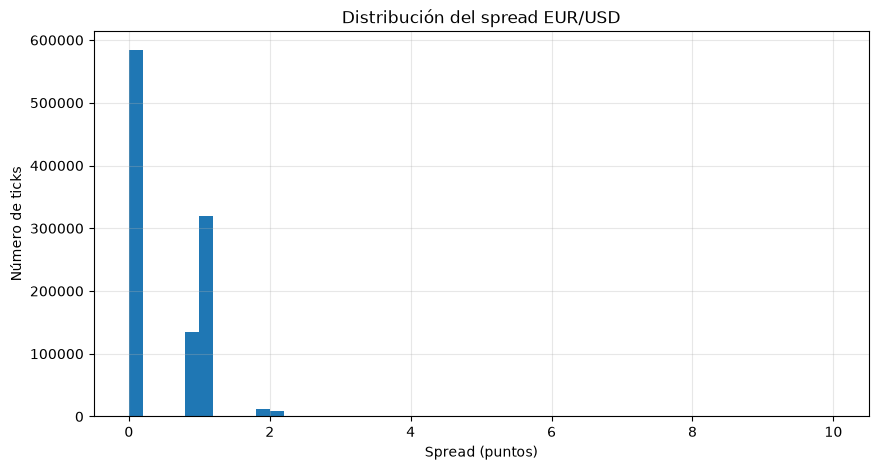

In [21]:
plot_limit = (
    ticks_analysis["spread_points"]
    .quantile(0.999)
)


spread_for_plot = (
    ticks_analysis.loc[
        ticks_analysis["spread_points"]
        <= plot_limit,
        "spread_points"
    ]
)


plt.figure(
    figsize=(10, 5)
)

plt.hist(
    spread_for_plot,
    bins=50
)

plt.title(
    "Distribución del spread EUR/USD"
)

plt.xlabel(
    "Spread (puntos)"
)

plt.ylabel(
    "Número de ticks"
)

plt.grid(
    alpha=0.3
)

plt.show()

## 21. Visualizar el spread medio y mediano por hora

Esta gráfica permite observar si determinadas horas del servidor MT5
presentan sistemáticamente spreads más elevados.

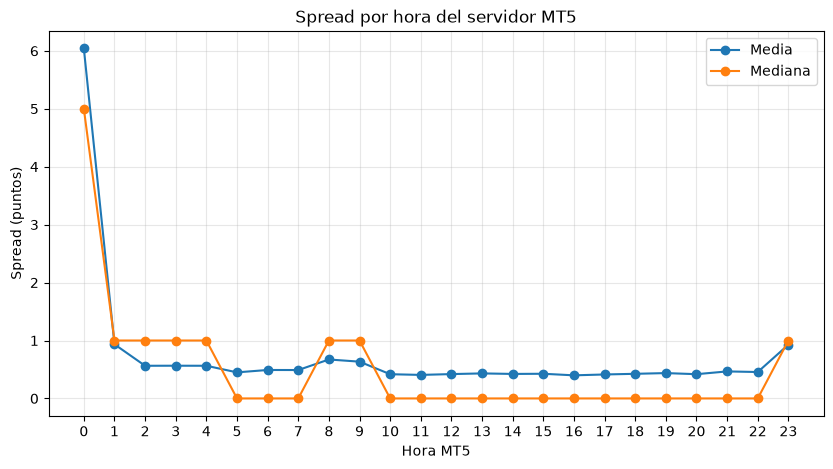

In [22]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    spread_by_hour.index,
    spread_by_hour["mean"],
    marker="o",
    label="Media"
)

plt.plot(
    spread_by_hour.index,
    spread_by_hour["median"],
    marker="o",
    label="Mediana"
)

plt.title(
    "Spread por hora del servidor MT5"
)

plt.xlabel(
    "Hora MT5"
)

plt.ylabel(
    "Spread (puntos)"
)

plt.xticks(
    range(24)
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## 22. Agregar el spread por minuto

Los ticks llegan de forma irregular.

Para observar mejor la evolución temporal agruparemos los ticks por
minuto y calcularemos:

- Número de ticks.
- Spread medio.
- Spread mediano.
- Spread máximo.

Esta tabla es únicamente una transformación para análisis.

In [23]:
spread_by_minute = (
    ticks_analysis
    .set_index("time")
    ["spread_points"]
    .resample("1min")
    .agg(
        ticks="count",
        mean="mean",
        median="median",
        maximum="max"
    )
)


spread_by_minute = (
    spread_by_minute[
        spread_by_minute["ticks"] > 0
    ]
    .copy()
)


print(
    "Minutos con ticks:",
    len(spread_by_minute)
)


display(
    spread_by_minute.head(20)
)

Minutos con ticks: 7200


,ticks,mean,median,maximum
time,,,,
2026-09-01 00:17:00+00:00,14,6.214286,7.5,10.0
2026-09-01 00:18:00+00:00,4,3.250000,3.0,5.0
2026-09-01 00:19:00+00:00,3,3.666667,4.0,5.0
2026-09-01 00:20:00+00:00,6,5.833333,5.5,8.0
2026-09-01 00:21:00+00:00,1,8.000000,8.0,8.0
2026-09-01 00:22:00+00:00,21,8.238095,8.0,9.0
2026-09-01 00:23:00+00:00,2,9.500000,9.5,10.0
2026-09-01 00:24:00+00:00,10,9.300000,9.5,10.0
2026-09-01 00:25:00+00:00,8,6.250000,6.0,7.0


## 23. Visualizar la evolución temporal del spread

Representamos el spread mediano por minuto.

Esto nos permitirá observar períodos en los que las condiciones de
ejecución empeoran temporalmente.

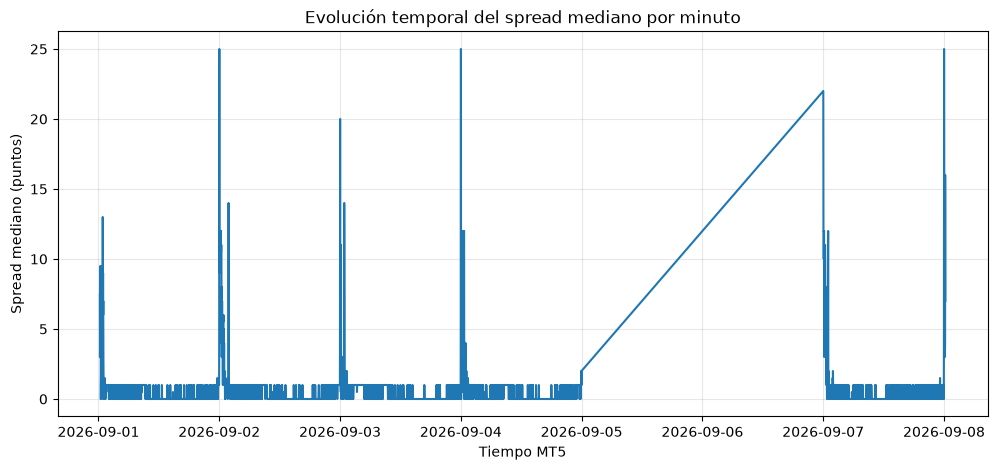

In [24]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    spread_by_minute.index,
    spread_by_minute["median"]
)

plt.title(
    "Evolución temporal del spread mediano por minuto"
)

plt.xlabel(
    "Tiempo MT5"
)

plt.ylabel(
    "Spread mediano (puntos)"
)

plt.grid(
    alpha=0.3
)

plt.show()

## 24. Resumen de la Fase 3

Creamos una tabla final con las principales características de la base
de ticks y del spread.

In [25]:
phase3_summary = pd.DataFrame(
    [
        {
            "metrica": "Ticks originales",
            "valor": len(ticks_raw)
        },

        {
            "metrica": "Duplicados exactos eliminados",
            "valor": n_exact_duplicates
        },

        {
            "metrica": "Ticks limpios",
            "valor": len(ticks_clean)
        },

        {
            "metrica": "Duplicados exactos restantes",
            "valor": remaining_exact_duplicates
        },

        {
            "metrica": "Bid <= 0",
            "valor": bid_invalid
        },

        {
            "metrica": "Ask <= 0",
            "valor": ask_invalid
        },

        {
            "metrica": "Ask < Bid",
            "valor": ask_below_bid
        },

        {
            "metrica": "Spread negativo",
            "valor": negative_spread
        },

        {
            "metrica": "Spread medio (puntos)",
            "valor": ticks_analysis[
                "spread_points"
            ].mean()
        },

        {
            "metrica": "Spread mediano (puntos)",
            "valor": ticks_analysis[
                "spread_points"
            ].median()
        },

        {
            "metrica": "Spread P95 (puntos)",
            "valor": ticks_analysis[
                "spread_points"
            ].quantile(0.95)
        },

        {
            "metrica": "Spread P99 (puntos)",
            "valor": ticks_analysis[
                "spread_points"
            ].quantile(0.99)
        },

        {
            "metrica": "Spread máximo (puntos)",
            "valor": ticks_analysis[
                "spread_points"
            ].max()
        },

        {
            "metrica": "Ticks con spread cero",
            "valor": zero_spread_count
        },

        {
            "metrica": "Spread cero (%)",
            "valor": zero_spread_pct
        }
    ]
)


display(
    phase3_summary
)

,metrica,valor
0,Ticks originales,1.064413e+06
1,Duplicados exactos eliminados,2.560000e+02
2,Ticks limpios,1.064157e+06
3,Duplicados exactos restantes,0.000000e+00
4,Bid <= 0,0.000000e+00
5,Ask <= 0,0.000000e+00
6,Ask < Bid,0.000000e+00
7,Spread negativo,0.000000e+00
8,Spread medio (puntos),4.961890e-01
9,Spread mediano (puntos),0.000000e+00


# Conclusión de la Fase 3

En esta fase hemos creado una base de ticks procesada eliminando
únicamente los duplicados exactos.

El archivo original permanece intacto en `data/raw/`.

La nueva base limpia se encuentra en `data/processed/` y será utilizada
en los análisis posteriores.

También hemos estudiado la distribución del spread Bid/Ask, sus valores
habituales, sus percentiles, los episodios extremos y su comportamiento
según la hora y a través del tiempo.

Estos resultados serán fundamentales para construir posteriormente un
modelo de ejecución realista.

La siguiente fase será:

`04_execution_model.ipynb`